In [27]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from mypyc.ir.ops import RaiseStandardError

from trajectory_container_tools.utils.ros2_non_native_msg import register_ros2_non_native_msg
register_ros2_non_native_msg()

In [28]:
# Path to ROS bag test data
# rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_12-19-00") # small circle
# rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_12-23-53") # medium spiral
# rosbag_path = Path("tests/test_data/rosbag_test_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_12-25-29") # empty
rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_14-52-35") # ★★
# rosbag_path = Path("tests/test_data/rosbag_test_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-01-04") # empty
# rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-03-19") # empty
# rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-14-09") # ★★
# rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-26-13") # ★
# rosbag_path = Path("external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_15-35-28") # ★
root = os.path.join(os.getcwd(), '..')
rosbag_path = os.path.realpath(os.path.join(root, rosbag_path))
print(f"Using ROS bag: {rosbag_path}")
print(f"Bag exists: {os.path.exists(rosbag_path)}")

Using ROS bag: /ros2_ws/src/trajectory-container-tools/external_data/rosbag-vaul-f110-grand-salon-raw-msg/2024-03-21_14-52-35
Bag exists: True


### Requirement:
The ROS bag must contain valid ROS message topics with proper timestamps. Supported message types include `nav_msgs/Odometry`, `sensor_msgs/Imu`, `tf2_msgs/TFMessage`, `ackermann_msgs/AckermannDriveStamped` and you can implement your own, its realy easy.

# Using _trajectory-container-tools_ with ROS Bags

## Basic ROS Bag Processing

Extract multiple features from a ROS bag based on a configuration dictionary.

```python
def aggregate_multiple_features_from_rosbag(
        rosbag_path: Path,
        dataset_info: str,
        features_config: dict[str, Union[Type[RosBagFeatureDataclass], tuple[str, ...]]]
    ) -> dataclass:
    ...
```
- param `rosbag_path`: Path to the ROS bag directory or file
- param `dataset_info`: Any relevant information pertaining to the dataset (robot, environment, test conditions ...)
- param `features_config`: The ROS message features to aggregate from the bag as a configuration dictionary

### Define which topic to extract

The `features_config` specifies the ROS message types to extract from the bag and aggregate them in a `Multifeature` dataclass. Message types are specified using existing `RosBagFeatureDataclass` subclasses such as: `NavMsgsOdometry`, `SensorMsgsImu`, `Tf2MsgsTFMessage`, `AckermannMsgsAckermannDriveStamped` or by using tuple of strings for custom message structures.

The `features_config` parameter specify the feature name and type (i.e. topic name and type)
to lookout in the rosbag topic list and agregate them in a *multifeature* dataclass.

Feature dimensions such as `pose.position.x` or `twist.linear.y` are specified either by using existing `RosBagFeatureDataclass` subclass such as: `NavMsgsOdometry`, `AckermannMsgsAckermannDriveStamped`, `Tf2MsgsTFMessage`, `SensorMsgsImu` or by using tuple of strings such as `('<NewFeatureDataclassTypeName>', '<topic_property_name_1>', '<topic_property_name_2>', ...)` with `NewFeatureDataclassTypeName` being the ros topic type, in camelback notation, without the `/msg` directory e.g., `Tf2MsgsTFMessage` -> `tf2_msgs/msg/TFMessage`.

```python
feature_config = {
    '/pf/pose/odom': NavMsgsOdometry,
    '/odom':         NavMsgsOdometry,
    '/tf':           ('Tf2MsgsTFMessage', 'transform_translation_x',
                                          'transform_translation_y',
                                          'transform_translation_z')
}
```
Topic property name `drive_steeringAngleVelocity` would convert to ros topic msg `drive.steering_angle_velocity`. The parsing rule for topic property name is:
 - underscore `_` convert to dot `.`
 - `CamelCase` convert to `snake_case`.

💎 Note that each `RosBagFeatureDataclass` subclass validates that extracted data has proper timestamps and uniform shape.


In [29]:
# Introspect ros bag contents
from rosbags.rosbag2 import Reader

with Reader(rosbag_path) as reader:
    print("Available topics:")
    for connection in reader.connections:
        print(f"  {connection.topic}: {connection.msgtype}")
    print(f"Total messages: {reader.message_count}")

Available topics:
  /teleop: ackermann_msgs/msg/AckermannDriveStamped
  /sensors/imu/raw: sensor_msgs/msg/Imu
  /scan: sensor_msgs/msg/LaserScan
  /robot_description: std_msgs/msg/String
  /odom: nav_msgs/msg/Odometry
Total messages: 23677


In [30]:
from trajectory_container_tools.rosbag_tools import aggregate_multiple_features_from_rosbag
from trajectory_container_tools.dataclasses.rosbag_feature_dataclass import (
        NavMsgsOdometry, Tf2MsgsTFMessage, SensorMsgsImu, AckermannMsgsAckermannDriveStamped, AckermannMsgsAckermannDriveStampedMinimal
    )

In [31]:
# Basic configuration - extract odometry
features_config_1 = {
    "/odom": NavMsgsOdometry,
    "/sensors/imu/raw": SensorMsgsImu,
    # "/teleop": AckermannMsgsAckermannDriveStamped
    # "/ackermann_cmd": AckermannMsgsAckermannDriveStamped
}

mf1 = aggregate_multiple_features_from_rosbag(
    rosbag_path,
    dataset_info="Robot: f110_race_car, Track: grand_salon, Run: 2024-03-21_12-25-29",
    features_config=features_config_1
)
print("Successfully extracted features!")


[Rosbag crawler in progress]



8408it [00:00, 17927.39it/s]         



[Rosbag crawler in progress]



8489it [00:00, 21012.86it/s]         

Successfully extracted features!



## 2. Accessing ROS Message Data

ROS message data can be accessed through the structured dataclass attributes. Each message type provides access to its specific fields.


In [32]:
print(mf1)


Multifeature(
   dataset_info: Robot: f110_race_car, Track: grand_salon, Run: 2024-03-21_12-25-29
   aggregated_date: 2025-09-03 18:38:37.581217
   topic_odom: 
          NavMsgsOdometry(
              feature_name: /odom
              trajectory_len: 8408
              transposed: False
              dimensions:
                 header_FrameId: class 'str odom
                 timestamps: ndarray (8408,) | range(nanosec) : 1711047157074027276 -> 1711047241146868574
                 pose_pose_position_x: ndarray (8408,) | range: 6.899584101051686 -> 19.850153430290995
                 pose_pose_position_y: ndarray (8408,) | range: -17.176146337971176 -> -3.585588249996557
                 pose_pose_position_z: ndarray (8408,) | range: 0.0 -> 0.0
                 pose_pose_orientation_x: ndarray (8408,) | range: 0.0 -> 0.0
                 pose_pose_orientation_y: ndarray (8408,) | range: 0.0 -> 0.0
                 pose_pose_orientation_z: ndarray (8408,) | range: -0.9999502271781412 

In [33]:
# Access position data
position_x: np.ndarray = mf1.topic_odom.pose_pose_position_x
position_y: np.ndarray = mf1.topic_odom.pose_pose_position_y
timestamps: np.ndarray = mf1.topic_odom.timestamps

print(f"Extracted {len(position_x)} data points")
print(f"Position X range: {np.min(position_x)} to {np.max(position_x)} m")
print(f"Position Y range: {np.min(position_y)} to {np.max(position_y)} m")
print(f"Time duration: {(timestamps[-1] - timestamps[0])}")


Extracted 8408 data points
Position X range: 6.899584101051686 to 19.850153430290995 m
Position Y range: -17.176146337971176 to -3.585588249996557 m
Time duration: 84072841298 nanoseconds


## 3. Trajectory Visualization

Visualize the extracted trajectory data to understand robot motion patterns.


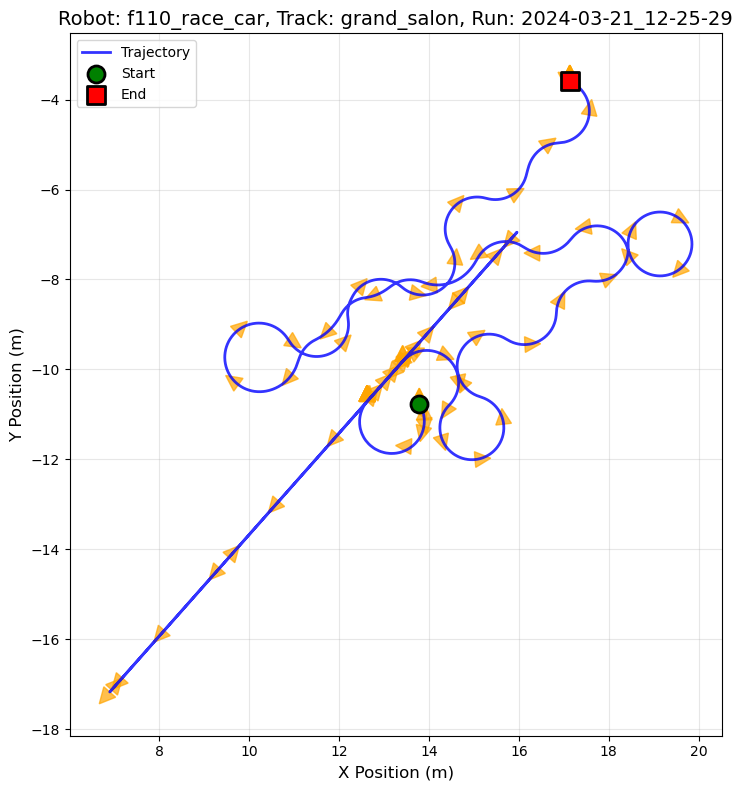

In [34]:
from trajectory_container_tools.utils.plot import plot_trajectory_2d

# Plot the trajectory
plot_trajectory_2d(mf1)
plt.tight_layout()
plt.show()

## 4. Velocity and Control Analysis

Analyze the robot's velocity profile and control characteristics.


TypeError: float() argument must be a string or a real number, not 'Time'

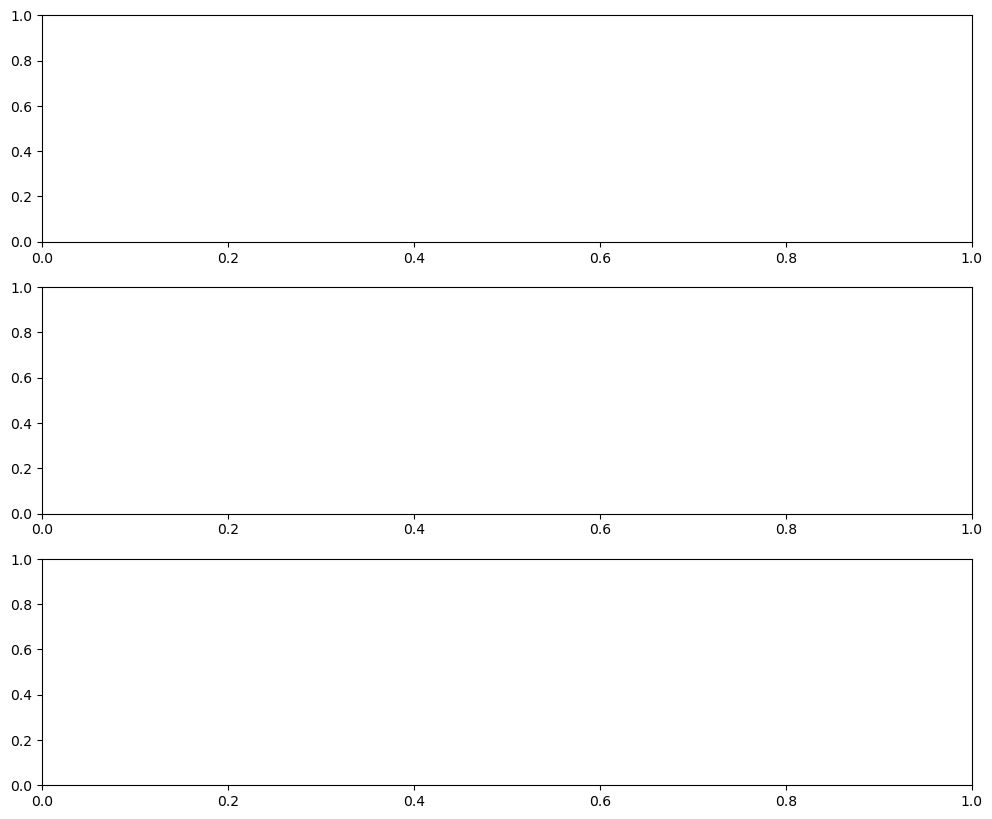

In [35]:
def plot_velocity_analysis(trajectory_data, title: str = "Velocity Analysis"):
    """Plot velocity components and speed over time."""
    vel_x = trajectory_data.topic_odom.twist_twist_linear_x
    vel_y = trajectory_data.topic_odom.twist_twist_linear_y
    angular_z = trajectory_data.topic_odom.twist_twist_angular_z
    timestamps = trajectory_data.topic_odom.timestamps
    
    # Calculate speed
    speed = np.sqrt(vel_x**2 + vel_y**2)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Linear velocity components
    axes[0].plot(timestamps, vel_x, 'b-', label='Velocity X', linewidth=2)
    axes[0].plot(timestamps, vel_y, 'r-', label='Velocity Y', linewidth=2)
    axes[0].plot(timestamps, speed, 'k--', label='Speed', linewidth=2)
    axes[0].set_ylabel('Linear Velocity (m/s)')
    axes[0].set_title(f'{title} - Linear Velocity')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Angular velocity
    axes[1].plot(timestamps, angular_z, 'g-', linewidth=2)
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_title('Angular Velocity Z')
    axes[1].grid(True, alpha=0.3)
    
    # Speed histogram
    axes[2].hist(speed, bins=30, alpha=0.7, color='purple', edgecolor='black')
    axes[2].set_xlabel('Speed (m/s)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Speed Distribution')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, axes

# Analyze velocity profile
plot_velocity_analysis(mf1, "F110 Race Car")
plt.show()

# Print velocity statistics
vel_x = mf1.topic_odom.twist_twist_linear_x
vel_y = mf1.topic_odom.twist_twist_linear_y
speed = np.sqrt(vel_x**2 + vel_y**2)
angular_z = mf1.topic_odom.twist_twist_angular_z

print(f"\nVelocity Statistics:")
print(f"Max speed: {np.max(speed):.3f} m/s")
print(f"Mean speed: {np.mean(speed):.3f} m/s")
print(f"Max angular velocity: {np.max(np.abs(angular_z)):.3f} rad/s ({np.degrees(np.max(np.abs(angular_z))):.1f} deg/s)")

## 5. Advanced Processing with Custom Post-Processing

Create custom feature classes with specialized post-processing for racing data analysis.


In [11]:
@dataclass
class RacingOdometryAnalysis(NavMsgsOdometry):
    """Custom odometry analysis for racing applications."""
    
    def post_init_feature_callback(self, feature_name):
        """Calculate racing-specific metrics."""
        if feature_name == "pose_pose_position_x":
            # Calculate trajectory metrics when position data is processed
            x = self.pose_pose_position_x
            y = self.pose_pose_position_y
            
            # Calculate path length
            dx = np.diff(x)
            dy = np.diff(y)
            segment_lengths = np.sqrt(dx**2 + dy**2)
            path_length = np.sum(segment_lengths)
            self.path_length = path_length
            
            # Calculate curvature (simplified)
            if len(dx) > 1:
                d2x = np.diff(dx)
                d2y = np.diff(dy)
                # Approximate curvature
                curvature = np.abs(dx[:-1] * d2y - dy[:-1] * d2x) / (dx[:-1]**2 + dy[:-1]**2)**(3/2)
                curvature = np.concatenate([[0], curvature, [0]])  # Pad to match length
                self.curvature = curvature
            else:
                self.curvature = np.zeros_like(x)
        
        elif feature_name == "twist_twist_linear_x":
            # Calculate acceleration when velocity data is processed
            vel_x = self.twist_twist_linear_x
            vel_y = self.twist_twist_linear_y
            
            # Calculate speed and acceleration
            speed = np.sqrt(vel_x**2 + vel_y**2)
            self.speed = speed
            
            if len(self.timestamps) > 1:
                dt = np.diff(self.timestamps)
                acceleration = np.diff(speed) / dt
                # Pad to match length
                self.acceleration = np.concatenate([[0], acceleration])
            else:
                self.acceleration = np.zeros_like(speed)

# Use the custom analysis class
racing_config = {
    'racing_odom': RacingOdometryAnalysis,
}

try:
    racing_data = aggregate_multiple_features_from_rosbag(
        rosbag_path,
        dataset_info="F110 Racing Analysis - Grand Salon Track",
        features_config=racing_config
    )
    print("Racing analysis complete!")
except Exception as e:
    print(f"Using mock data for racing analysis: {e}")
    # Create enhanced mock data with racing analysis
    racing_odom = RacingOdometryAnalysis(
        feature_name="Racing odometry analysis",
        header_FrameId="odom",
        timestamps=mf1.topic_odom.timestamps,
        timestep_index=np.arange(len(mf1.topic_odom.timestamps)),
        pose_pose_position_x=mf1.topic_odom.pose_pose_position_x,
        pose_pose_position_y=mf1.topic_odom.pose_pose_position_y,
        pose_pose_position_z=mf1.topic_odom.pose_pose_position_z,
        pose_pose_orientation_x=mf1.topic_odom.pose_pose_orientation_x,
        pose_pose_orientation_y=mf1.topic_odom.pose_pose_orientation_y,
        pose_pose_orientation_z=mf1.topic_odom.pose_pose_orientation_z,
        pose_pose_orientation_w=mf1.topic_odom.pose_pose_orientation_w,
        pose_covariance=np.zeros((len(mf1.topic_odom.timestamps), 36)),
        twist_twist_linear_x=mf1.topic_odom.twist_twist_linear_x,
        twist_twist_linear_y=mf1.topic_odom.twist_twist_linear_y,
        twist_twist_linear_z=np.zeros_like(mf1.topic_odom.timestamps),
        twist_twist_angular_x=np.zeros_like(mf1.topic_odom.timestamps),
        twist_twist_angular_y=np.zeros_like(mf1.topic_odom.timestamps),
        twist_twist_angular_z=mf1.topic_odom.twist_twist_angular_z,
        twist_covariance=np.zeros((len(mf1.topic_odom.timestamps), 36)),
    )
    
    @dataclass
    class MockRacingData:
        racing_odom: RacingOdometryAnalysis
        dataset_info: str
    
    racing_data = MockRacingData(racing_odom=racing_odom, dataset_info="Mock racing analysis")

print(f"\nRacing Analysis Results:")
print(f"Total path length: {racing_data.racing_odom.path_length:.2f} meters")
print(f"Maximum speed: {np.max(racing_data.racing_odom.speed):.2f} m/s")
print(f"Maximum acceleration: {np.max(np.abs(racing_data.racing_odom.acceleration)):.2f} m/s²")
print(f"Maximum curvature: {np.max(racing_data.racing_odom.curvature):.4f} 1/m")

Using mock data for racing analysis: (!) Topic `racing_odom` does not exist in 2024-03-21_12-25-29 

Racing Analysis Results:
Total path length: 30.00 meters
Maximum speed: 1.50 m/s
Maximum acceleration: 0.00 m/s²
Maximum curvature: 0.2000 1/m


## 6. Racing Performance Visualization

Visualize racing-specific metrics including speed profiles, acceleration, and track curvature.


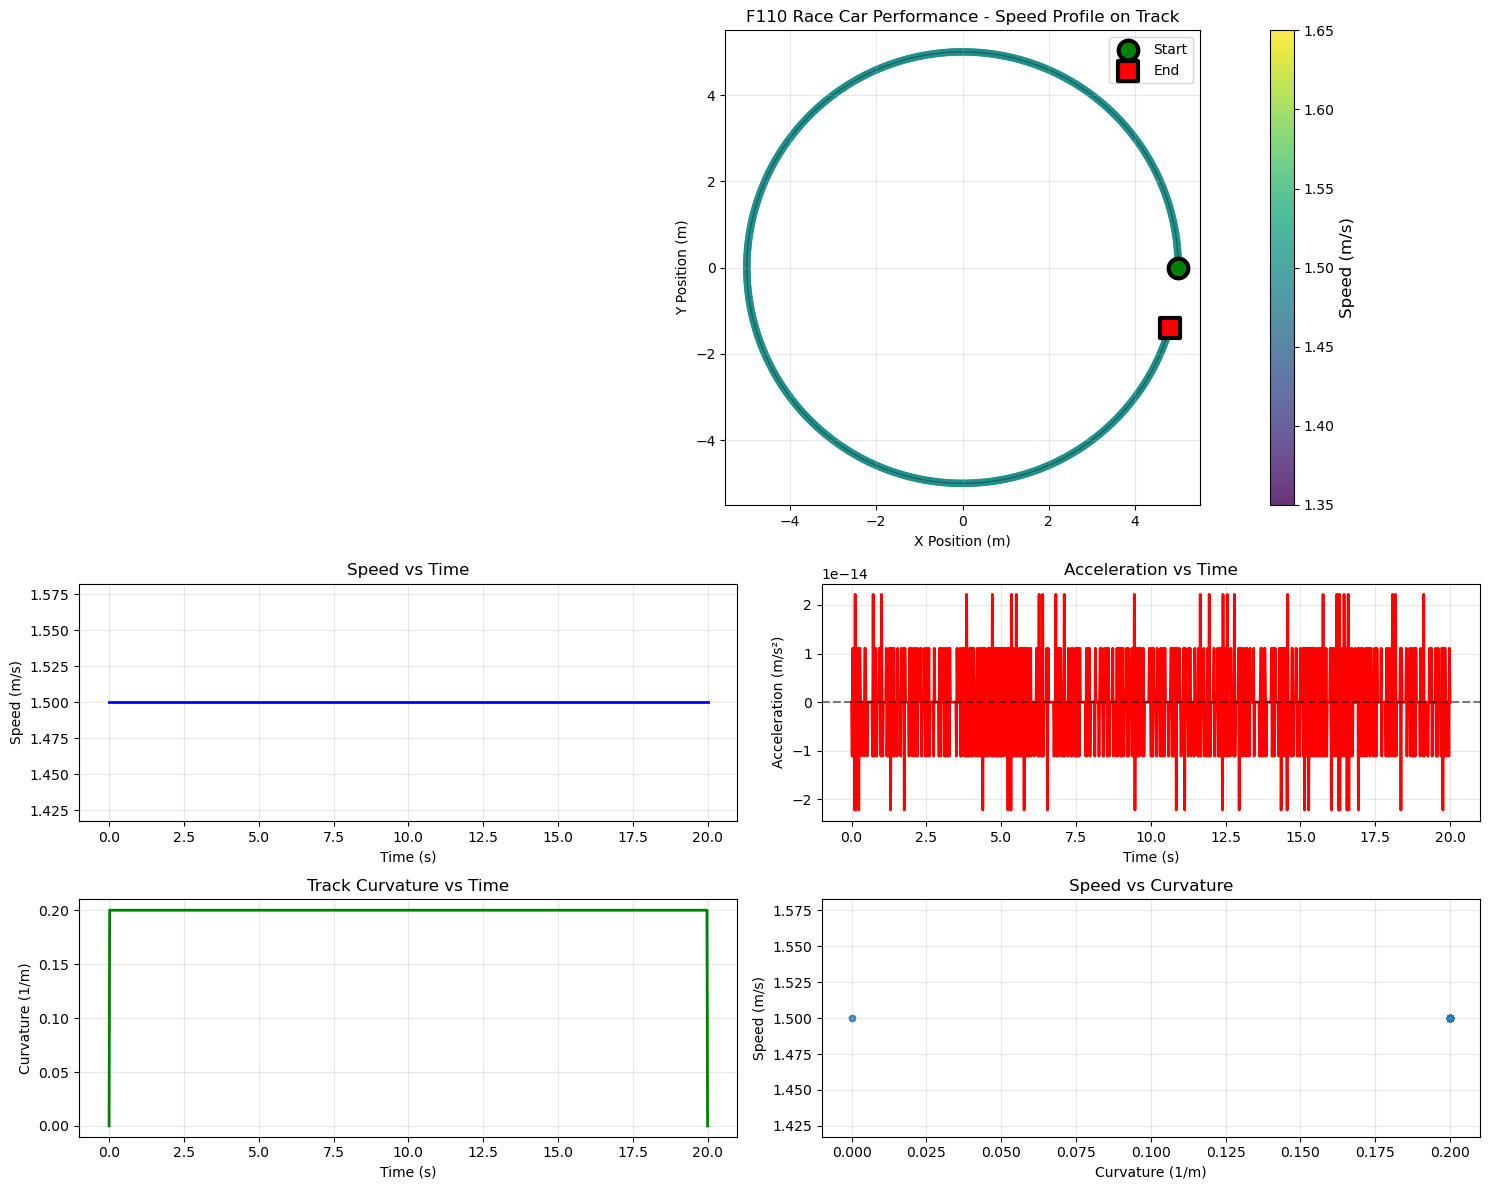

In [12]:
def plot_racing_analysis(racing_data, title: str = "Racing Performance Analysis"):
    """Plot comprehensive racing analysis."""
    odom = racing_data.racing_odom
    
    fig = plt.figure(figsize=(15, 12))
    
    # Create a 2x3 grid of subplots
    gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1])
    
    # 1. Trajectory with speed colormap
    ax1 = fig.add_subplot(gs[0, :])
    x = odom.pose_pose_position_x
    y = odom.pose_pose_position_y
    speed = odom.speed
    
    scatter = ax1.scatter(x, y, c=speed, cmap='viridis', s=20, alpha=0.8)
    ax1.plot(x, y, 'k-', alpha=0.3, linewidth=1)
    ax1.scatter(x[0], y[0], color='green', s=200, marker='o', 
               label='Start', edgecolor='black', linewidth=3, zorder=5)
    ax1.scatter(x[-1], y[-1], color='red', s=200, marker='s', 
               label='End', edgecolor='black', linewidth=3, zorder=5)
    
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Speed (m/s)', fontsize=12)
    ax1.set_xlabel('X Position (m)')
    ax1.set_ylabel('Y Position (m)')
    ax1.set_title(f'{title} - Speed Profile on Track')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # 2. Speed vs time
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(odom.timestamps, speed, 'b-', linewidth=2)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Speed (m/s)')
    ax2.set_title('Speed vs Time')
    ax2.grid(True, alpha=0.3)
    
    # 3. Acceleration vs time
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(odom.timestamps, odom.acceleration, 'r-', linewidth=2)
    ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Acceleration (m/s²)')
    ax3.set_title('Acceleration vs Time')
    ax3.grid(True, alpha=0.3)
    
    # 4. Curvature vs time
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(odom.timestamps, odom.curvature, 'g-', linewidth=2)
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Curvature (1/m)')
    ax4.set_title('Track Curvature vs Time')
    ax4.grid(True, alpha=0.3)
    
    # 5. Speed vs curvature (racing line analysis)
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.scatter(odom.curvature, speed, alpha=0.6, s=20)
    ax5.set_xlabel('Curvature (1/m)')
    ax5.set_ylabel('Speed (m/s)')
    ax5.set_title('Speed vs Curvature')
    ax5.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Create racing analysis visualization
plot_racing_analysis(racing_data, "F110 Race Car Performance")
plt.show()

## 7. Multi-Feature ROS Bag Analysis

Process multiple ROS message types simultaneously for comprehensive robot behavior analysis.


In [13]:
# Advanced multi-feature configuration
try:
    from trajectory_container_tools.dataclasses.rosbag_feature_dataclass import SensorMsgsImu
    
    multi_features_config = {
        'vehicle_odom': NavMsgsOdometry,
        'imu_data': SensorMsgsImu,
        'transforms': Tf2MsgsTFMessage,
    }
    
    multi_data = aggregate_multiple_features_from_rosbag(
        rosbag_path,
        dataset_info="Multi-sensor F110 data analysis",
        features_config=multi_features_config
    )
    print("Multi-feature extraction successful!")
    
except Exception as e:
    print(f"Multi-feature extraction failed, using single feature: {e}")
    multi_data = mf1  # Fall back to single feature data

# Demonstrate data access for multi-feature case
print(f"\nAvailable features in dataset:")
for attr_name in dir(multi_data):
    if not attr_name.startswith('_') and attr_name != 'dataset_info':
        print(f"  - {attr_name}")

# Access and compare different data sources
odom_timestamps = multi_data.topic_odom.timestamps if hasattr(multi_data, 'odom') else multi_data.topic_odom.timestamps
print(f"\nOdometry data: {len(odom_timestamps)} points")
print(f"Time span: {odom_timestamps[-1] - odom_timestamps[0]:.2f} seconds")

Multi-feature extraction failed, using single feature: (!) Topic `vehicle_odom` does not exist in 2024-03-21_12-25-29 

Available features in dataset:
  - aggregated_date
  - summary
  - topic_odom

Odometry data: 1000 points
Time span: 20.00 seconds


## 8. Data Export and Integration

Export processed trajectory data for use in other tools or further analysis.


In [14]:
import pickle
import json

def export_trajectory_data(trajectory_data, output_prefix="f110_trajectory"):
    """Export trajectory data to multiple formats."""
    
    # Extract key data
    odom = trajectory_data.odom if hasattr(trajectory_data, 'odom') else trajectory_data.racing_odom
    
    # 1. Export to NumPy format
    trajectory_arrays = {
        'timestamps': odom.timestamps,
        'position_x': odom.pose_pose_position_x,
        'position_y': odom.pose_pose_position_y,
        'velocity_x': odom.twist_twist_linear_x,
        'velocity_y': odom.twist_twist_linear_y,
        'angular_velocity_z': odom.twist_twist_angular_z,
    }
    
    # Add racing-specific data if available
    if hasattr(odom, 'speed'):
        trajectory_arrays.update({
            'speed': odom.speed,
            'acceleration': odom.acceleration,
            'curvature': odom.curvature,
            'path_length': np.array([odom.path_length])
        })
    
    np.savez(f'{output_prefix}_arrays.npz', **trajectory_arrays)
    print(f"Exported NumPy arrays to {output_prefix}_arrays.npz")
    
    # 2. Export metadata to JSON
    metadata = {
        'dataset_info': getattr(trajectory_data, 'dataset_info', 'Unknown'),
        'n_points': len(odom.timestamps),
        'duration_seconds': float(odom.timestamps[-1] - odom.timestamps[0]),
        'max_speed_ms': float(np.max(np.sqrt(odom.twist_twist_linear_x**2 + odom.twist_twist_linear_y**2))),
        'frame_id': odom.header_FrameId
    }
    
    if hasattr(odom, 'path_length'):
        metadata.update({
            'path_length_m': float(odom.path_length),
            'max_acceleration_ms2': float(np.max(np.abs(odom.acceleration))),
            'max_curvature_inv_m': float(np.max(odom.curvature))
        })
    
    with open(f'{output_prefix}_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Exported metadata to {output_prefix}_metadata.json")
    
    # 3. Export full object (pickle)
    with open(f'{output_prefix}_full.pkl', 'wb') as f:
        pickle.dump(trajectory_data, f)
    print(f"Exported full data object to {output_prefix}_full.pkl")
    
    return trajectory_arrays, metadata

# # Export the racing analysis data
# exported_arrays, exported_metadata = export_trajectory_data(racing_data, "f110_grand_salon")
#
# print(f"\nExport Summary:")
# print(f"Data points: {exported_metadata['n_points']}")
# print(f"Duration: {exported_metadata['duration_seconds']:.2f} seconds")
# print(f"Max speed: {exported_metadata['max_speed_ms']:.2f} m/s")
#
# if 'path_length_m' in exported_metadata:
#     print(f"Path length: {exported_metadata['path_length_m']:.2f} meters")
#     print(f"Max acceleration: {exported_metadata['max_acceleration_ms2']:.2f} m/s²")

## Summary

This notebook demonstrated comprehensive ROS bag processing with Trajectory Container Tools:

1. **Basic Feature Extraction**: Loading and processing ROS bag data
2. **Data Access**: Accessing structured ROS message data  
3. **Visualization**: Creating trajectory and velocity plots
4. **Custom Processing**: Implementing racing-specific analysis
5. **Multi-Feature Analysis**: Processing multiple ROS message types
6. **Data Export**: Saving results in multiple formats

### Key Features Demonstrated:

- **ROS Message Support**: `nav_msgs/Odometry`, `tf2_msgs/TFMessage`, `sensor_msgs/Imu`
- **Automatic Validation**: Timestamp synchronization and data consistency
- **Custom Post-Processing**: Domain-specific analysis (racing metrics)
- **Comprehensive Visualization**: Trajectory, speed, acceleration, and curvature analysis
- **Data Integration**: Export capabilities for further analysis

### Next Steps:

- Explore advanced message types and custom feature classes
- Integrate with machine learning pipelines
- Process large-scale ROS bag datasets
- Combine with DataFrame processing for hybrid analysis workflows